In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("siddharthbhakta/tmdb-top-10000-movies-updated-2026")

print("Path to dataset files:", path)

100%|██████████| 1.32M/1.32M [00:01<00:00, 943kB/s]

Extracting files...
Path to dataset files: C:\Users\cadet\.cache\kagglehub\datasets\siddharthbhakta\tmdb-top-10000-movies-updated-2026\versions\1


In [ ]:
import os
import pandas as pd
df = pd.read_csv(os.path.join(path, "moviesTMBD.csv"))
df

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901
...,...,...,...,...,...,...,...,...,...,...
9975,9975,399173,The Assignment,2.1132,False,en,Ace assassin Frank Kitchen is double crossed b...,2016-06-08,5.538,560
9976,9976,613377,30 Days Max,1.2237,False,fr,Rayane is a scared and clumsy young cop who is...,2020-10-14,5.500,407
9977,9977,8859,"Dude, Where's My Car?",2.8157,False,en,Two stoners wake up after a night of partying ...,2000-12-15,5.538,2080
9978,9978,313943,Revolt,1.4022,False,en,The story of humankind's last stand against a ...,2017-07-01,5.537,393


In [10]:
df['release_date']=pd.to_datetime(df['release_date'])

Line plot

C:\Users\cadet\AppData\Local\Temp\ipykernel_26440\3533622464.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


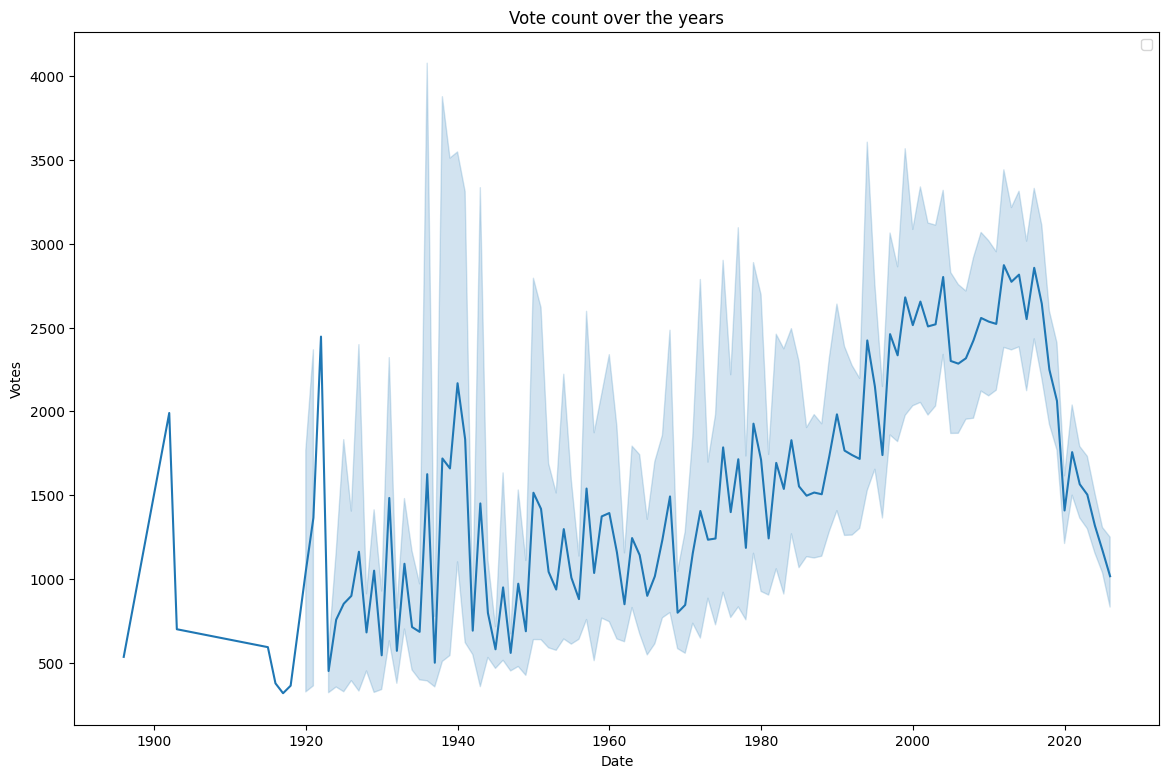

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,9))
sns.lineplot(data=df,x=df['release_date'].dt.year,y=df['vote_count'])
plt.xlabel('Date')
plt.ylabel('Votes')
plt.title('Vote count over the years')
plt.legend()
plt.show()


This line shart shows that over the year the vote count on the movies has increased with a random pattern but dropped after the years 2020 and also the votes were pretty high in the early 1920s

C:\Users\cadet\AppData\Local\Temp\ipykernel_26440\1432147274.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


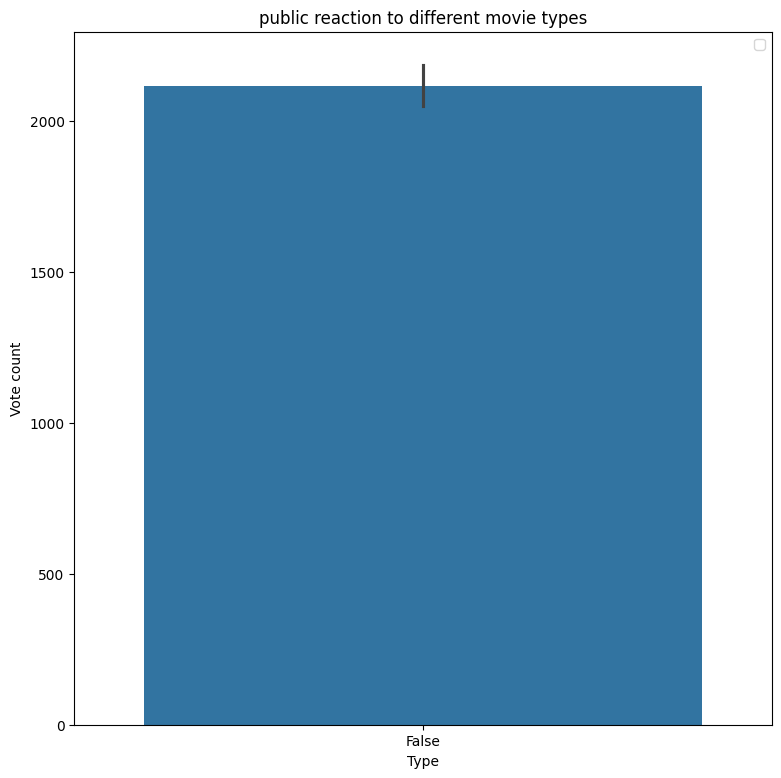

In [33]:
plt.figure(figsize=(9,9))
sns.barplot(data=df,x=df['adult'],y=df['vote_count'])
plt.xlabel('Type')
plt.ylabel('Vote count')
plt.title('public reaction to different movie types')
plt.legend()
plt.show()

In [18]:
print(df['adult'].value_counts())

adult
False    9980
Name: count, dtype: int64


this means the data set only consists of one category for the adult column and we can prune this column too , because this has only one type and adds no useful insight to the dataset

C:\Users\cadet\AppData\Local\Temp\ipykernel_26440\4000037502.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


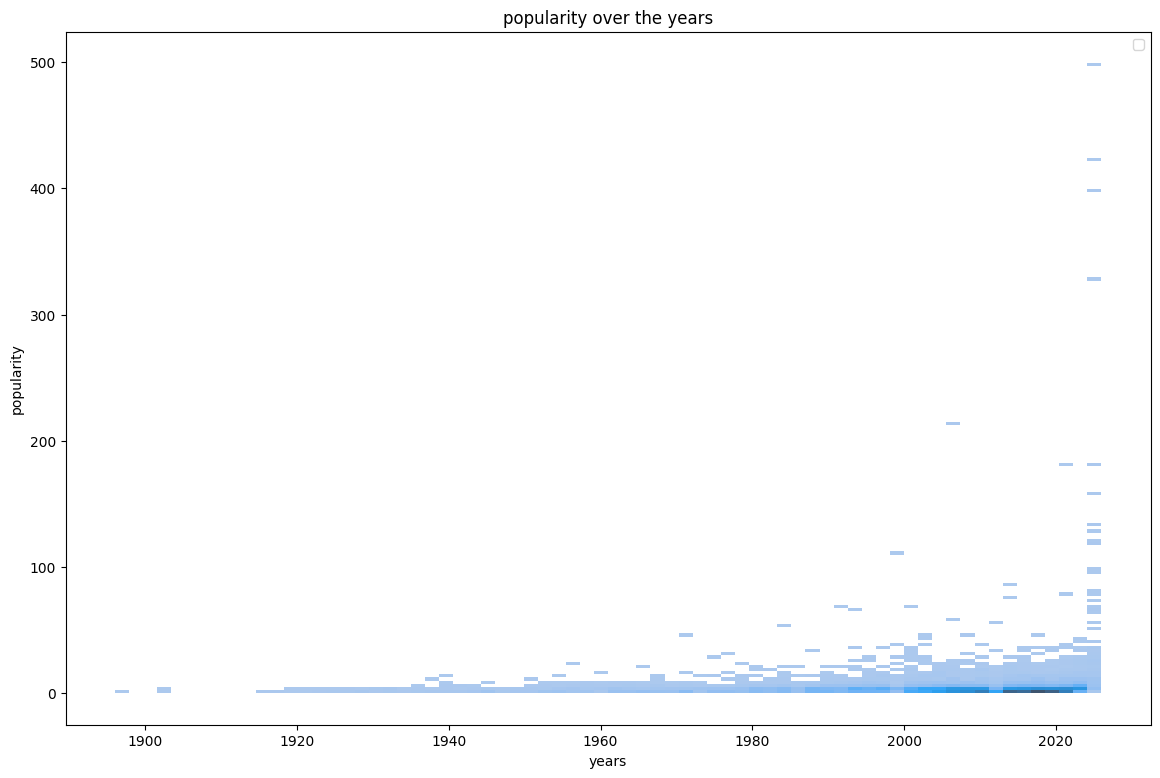

In [27]:
plt.figure(figsize=(14,9))
sns.histplot(data=df,x=df['release_date'].dt.year,y=df['popularity'])
plt.xlabel('years')
plt.ylabel('popularity')
plt.title('popularity over the years')
plt.legend()
plt.show()

this shows that the popularity distribution over the years is right skewed , it is at high values in the recent years than in the past years

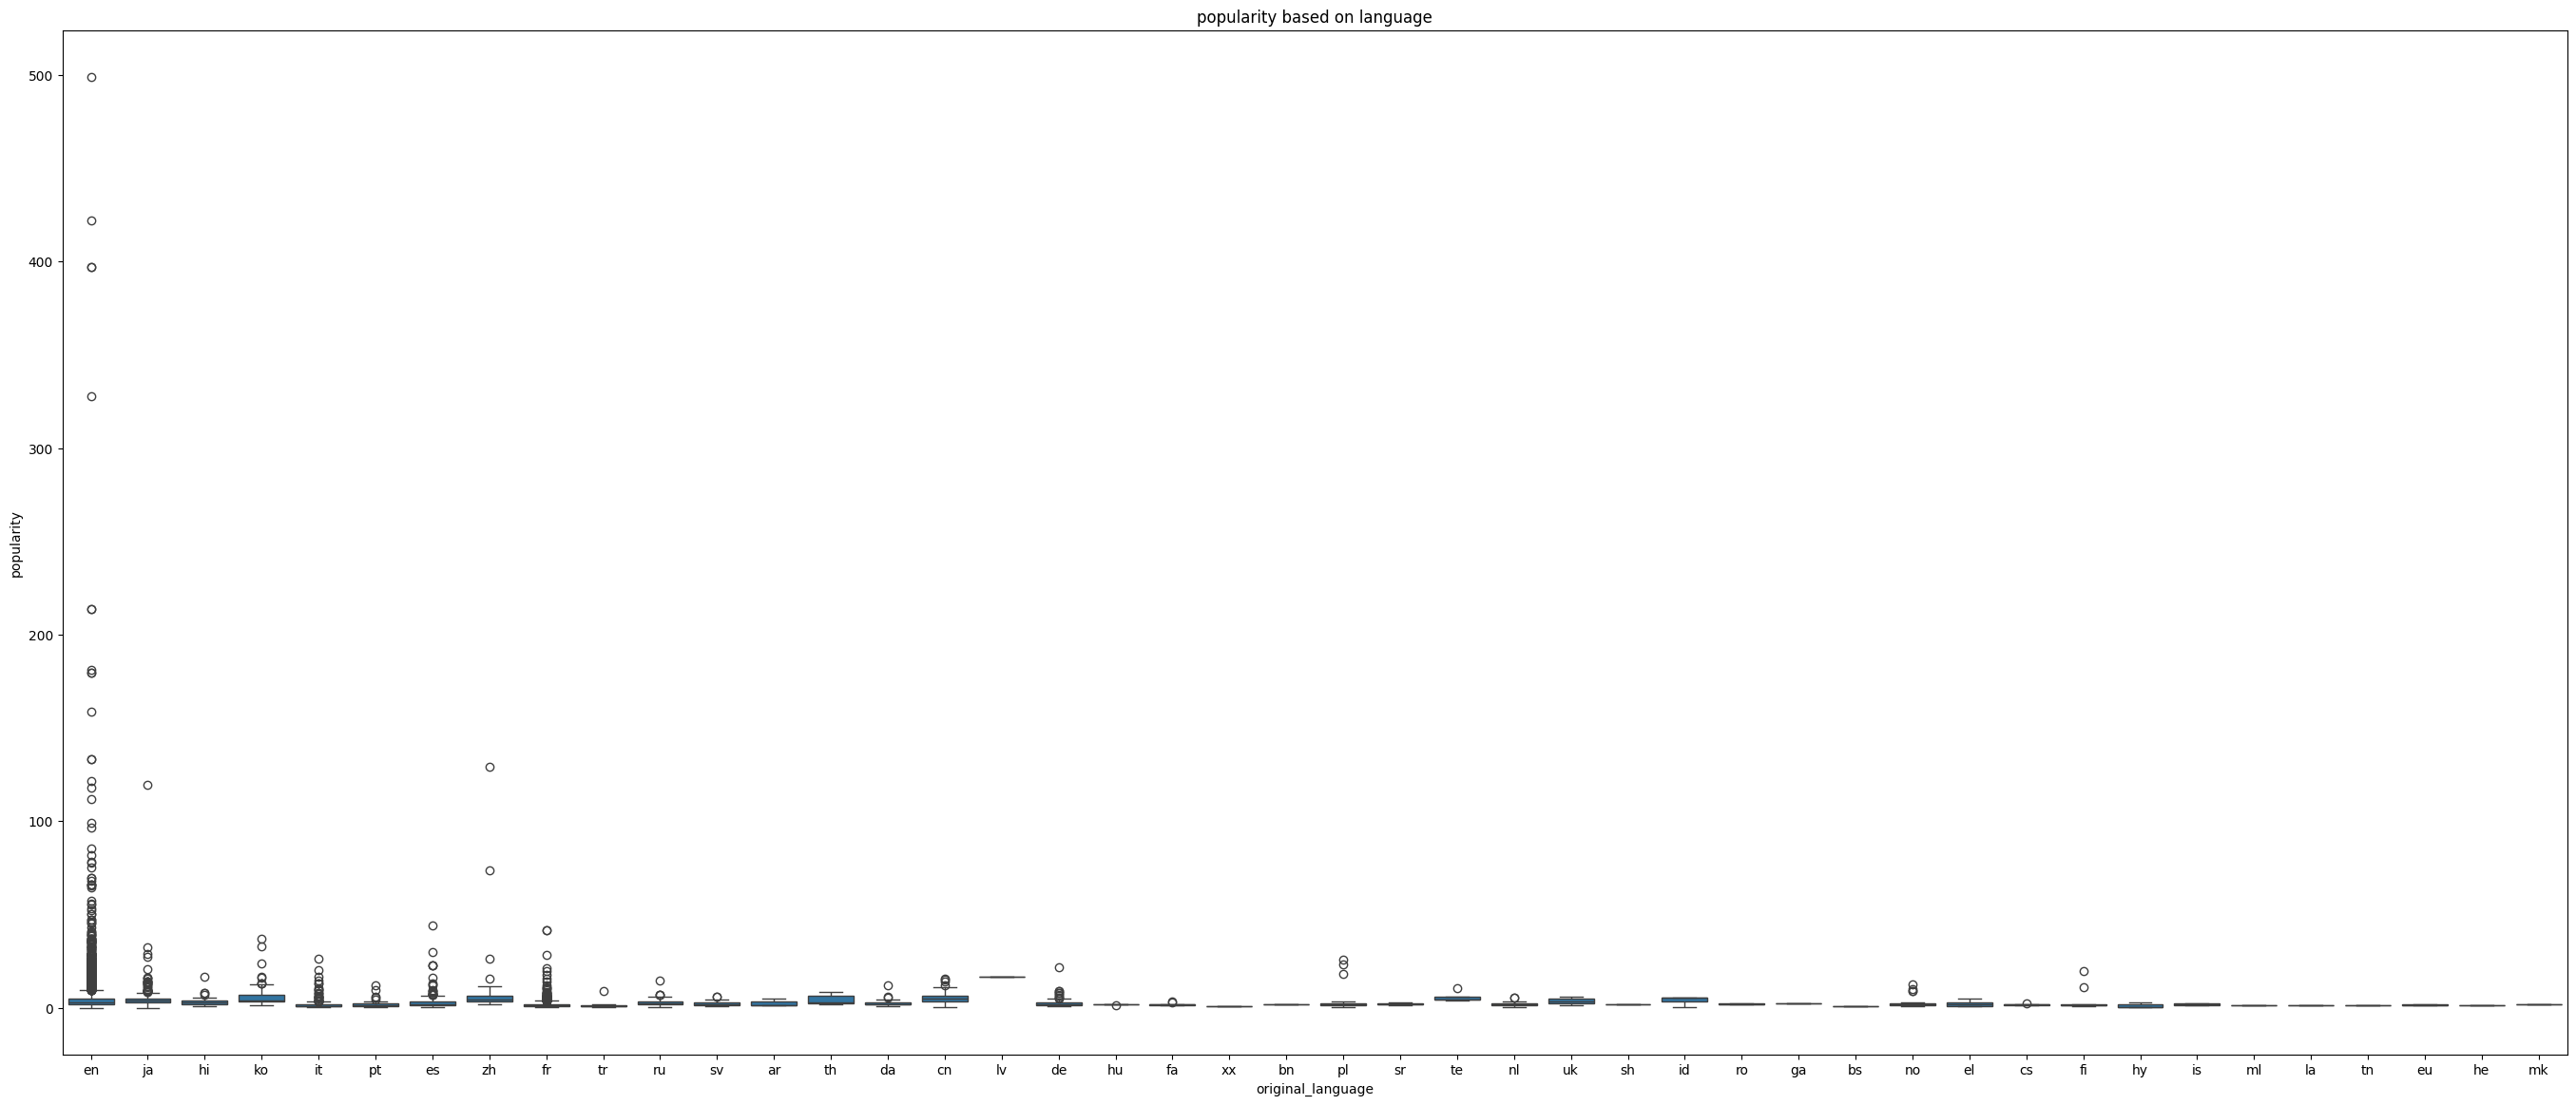

In [26]:
plt.figure(figsize=(34,14))
sns.boxplot(
    data=df,
    x='original_language',
    y='popularity'
)
plt.title('popularity based on language')
plt.show()

this shows that the english language will be dominating the dataset for this column as it has some far outliers while other languages dont have this type of variability

In [22]:
df.columns

Index(['Unnamed: 0', 'id', 'title', 'popularity', 'adult', 'original_language',
       'overview', 'release_date', 'vote_average', 'vote_count'],
      dtype='str')

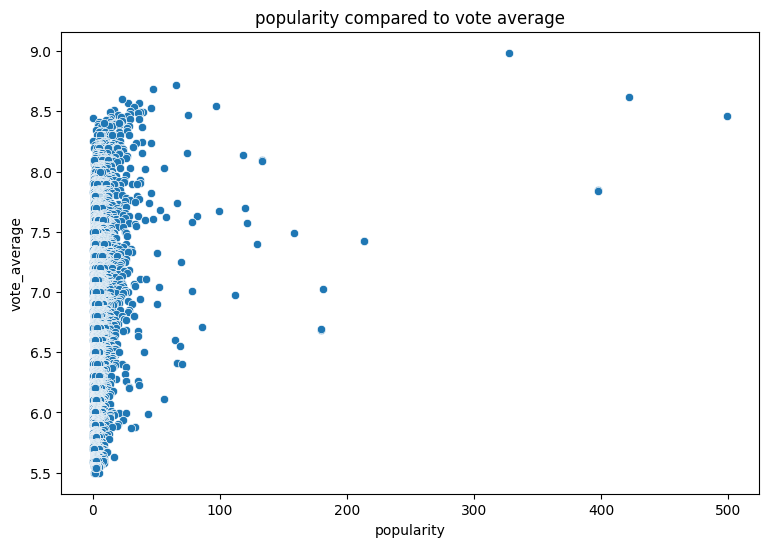

In [36]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='popularity',
    y='vote_average'
)
plt.title('popularity compared to vote average')
plt.show()

There is no strong linear relationship

If popularity strongly affected ratings, you would expect points to form a clear upward trend.

Instead, the points are scattered.

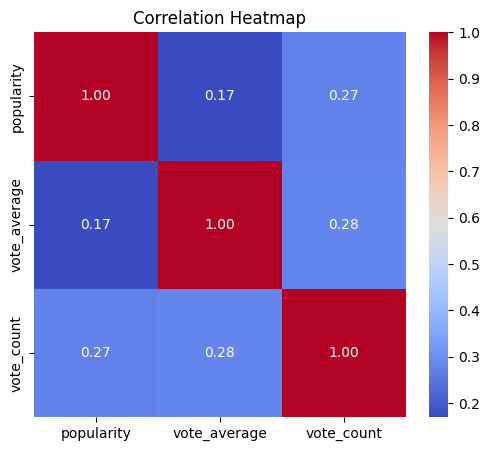

In [37]:
corr = df[['popularity', 'vote_average', 'vote_count']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

there is very little or upto none correlation between votecount popularity , which tells that these two columns are not very much affected by each other